# Pirminė duomenų analizė

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

PARQUET_PATH = 'signals.parquet'
SAMPLING_RATE = 51200

COL_FEATURE  = 'Feature'
COL_BANDYMAS = 'Bandymas'
COL_APKROVA  = 'Apkrova(Nm)'
COL_SUKIAI   = 'Sukiai(rpm)'
COL_SIGNAL   = 'Value'

## 1. Duomenų užkrovimas ir struktūra

In [2]:
df = pd.read_parquet(PARQUET_PATH)
df[COL_FEATURE]  = df[COL_FEATURE].str.replace('Feat', '').astype(int)
df[COL_BANDYMAS] = df[COL_BANDYMAS].str.extract(r'(\d+)').astype(int)
# Rekonstruojami signalai
signal_groups = df.groupby(
    [COL_FEATURE, COL_BANDYMAS, COL_APKROVA, COL_SUKIAI]
)[COL_SIGNAL].apply(np.array).reset_index()
signal_groups.columns = ['label', 'batch', 'load', 'rpm', 'signal']

# Pagrindine statistika
print(f'Iš viso signalų: {len(signal_groups)}')
print(f'Signalo ilgis: {len(signal_groups.iloc[0]["signal"]):,} reikšmės')
print(f'Diskretizavimo dažnis: {SAMPLING_RATE:,} Hz')
print(f'Signalo trukmė: {len(signal_groups.iloc[0]["signal"])/SAMPLING_RATE:.1f} s')
print(f'\nGedimų klasės: {sorted(signal_groups["label"].unique())}')
print(f'Bandymai: {sorted(signal_groups["batch"].unique())}')
print(f'Apkrovos (Nm): {sorted(signal_groups["load"].unique())}')
print(f'Sūkiai (RPM): {sorted(signal_groups["rpm"].unique())}')

print(f'\nSignalų skaičius pagal bandymą:')
for batch, cnt in signal_groups.groupby('batch').size().items():
    print(f'  Bandymas {batch}: {cnt}')

Iš viso signalų: 349
Signalo ilgis: 256,000 reikšmės
Diskretizavimo dažnis: 51,200 Hz
Signalo trukmė: 5.0 s

Gedimų klasės: [0, 1, 2, 3, 4, 5, 6]
Bandymai: [1, 2]
Apkrovos (Nm): [25, 50, 75, 100, 125]
Sūkiai (RPM): [1000, 2000, 3000, 4000, 5000]

Signalų skaičius pagal bandymą:
  Bandymas 1: 175
  Bandymas 2: 174


### Trūkstami signalai

In [3]:
# Tikriname ar visi gedimo/apkrovos/sukiu/bandymo kombinacijos egzistuoja
all_labels = signal_groups['label'].unique()
all_batches = signal_groups['batch'].unique()
all_loads = signal_groups['load'].unique()
all_rpms = signal_groups['rpm'].unique()

expected = set()
for l in all_labels:
    for b in all_batches:
        for load in all_loads:
            for rpm in all_rpms:
                expected.add((l, b, load, rpm))

actual = set(zip(
    signal_groups['label'], signal_groups['batch'],
    signal_groups['load'], signal_groups['rpm']
))

missing = expected - actual
if missing:
    print(f'Trūkstami signalai ({len(missing)}):')
    for m in sorted(missing):
        print(f'  Gedimas={m[0]}, Bandymas={m[1]}, '
              f'Apkrova={m[2]} Nm, Sūkiai={m[3]} RPM')
else:
    print('Visi signalai yra')

Trūkstami signalai (1):
  Gedimas=3, Bandymas=2, Apkrova=100 Nm, Sūkiai=2000 RPM


## 2. Signalų vizualizacija

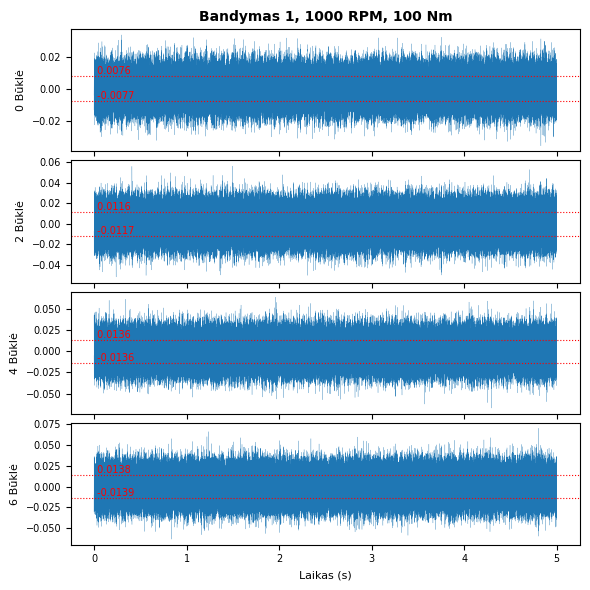

In [13]:
TARGET_RPM = 1000
TARGET_LOAD = 100
TARGET_BATCH = 1
SHOW_LABELS = [0, 2, 4, 6]
SHOW_SAMPLES = 256000
t = np.arange(SHOW_SAMPLES) / SAMPLING_RATE

fig, axes = plt.subplots(4, 1, figsize=(6, 6), sharex=True)

for ax, label in zip(axes, SHOW_LABELS):
    mask = (
        (signal_groups['rpm'] == TARGET_RPM) &
        (signal_groups['load'] == TARGET_LOAD) &
        (signal_groups['label'] == label) &
        (signal_groups['batch'] == TARGET_BATCH)
    )
    sig = signal_groups[mask].iloc[0]['signal'][:SHOW_SAMPLES]
    mean_val = np.mean(sig)
    std_val = np.std(sig)
    ax.plot(t, sig, linewidth=0.15)
    for val, lbl in [(mean_val + std_val, '+1σ'), (mean_val - std_val, '−1σ')]:
        ax.axhline(val, color='red', linewidth=0.8, linestyle=':')
        ax.text(t[0], val, f' {val:.4f}', va='bottom', fontsize=7, color='red')
    ax.set_ylabel(f'{label} Būklė', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_title(
    f'Bandymas {TARGET_BATCH}, {TARGET_RPM} RPM, {TARGET_LOAD} Nm',
    fontsize=10, fontweight='bold'
)
axes[-1].set_xlabel('Laikas (s)', fontsize=8)
plt.tight_layout(h_pad=0.3)
fig.savefig('signal_plot.png', dpi=300, bbox_inches='tight')
plt.show()

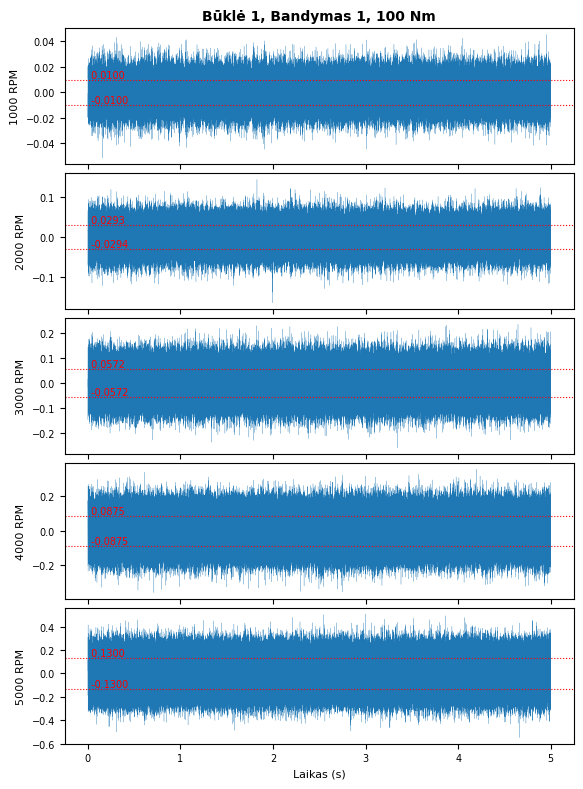

In [14]:
TARGET_LABEL = 1
TARGET_LOAD = 100
TARGET_BATCH = 1
RPMS = sorted(signal_groups['rpm'].unique())
SHOW_SAMPLES = 256000
t = np.arange(SHOW_SAMPLES) / SAMPLING_RATE

fig, axes = plt.subplots(len(RPMS), 1, figsize=(6, 8), sharex=True)

for ax, rpm in zip(axes, RPMS):
    mask = (
        (signal_groups['rpm'] == rpm) &
        (signal_groups['load'] == TARGET_LOAD) &
        (signal_groups['label'] == TARGET_LABEL) &
        (signal_groups['batch'] == TARGET_BATCH)
    )
    sig = signal_groups[mask].iloc[0]['signal'][:SHOW_SAMPLES]
    mean_val = np.mean(sig)
    std_val = np.std(sig)
    ax.plot(t, sig, linewidth=0.15)
    for val, lbl in [(mean_val + std_val, '+1σ'), (mean_val - std_val, '−1σ')]:
        ax.axhline(val, color='red', linewidth=0.8, linestyle=':')
        ax.text(t[0], val, f' {val:.4f}', va='bottom', fontsize=7, color='red')
    ax.set_ylabel(f'{rpm} RPM', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_title(
    f'Būklė {TARGET_LABEL}, Bandymas {TARGET_BATCH}, {TARGET_LOAD} Nm',
    fontsize=10, fontweight='bold'
)
axes[-1].set_xlabel('Laikas (s)', fontsize=8)
plt.tight_layout(h_pad=0.3)
fig.savefig('signal_plot2.png', dpi=300, bbox_inches='tight')
plt.show()

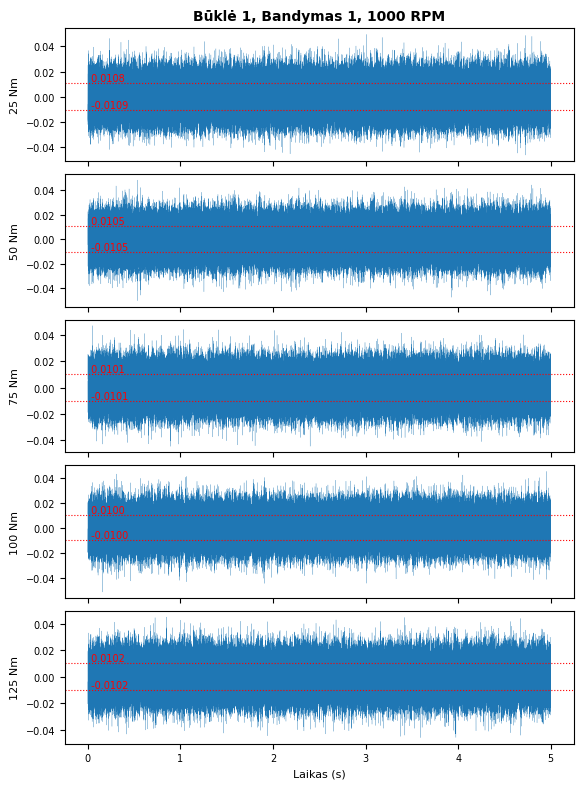

In [17]:
TARGET_LABEL = 1
TARGET_RPM = 1000
TARGET_BATCH = 1
LOADS = sorted(signal_groups['load'].unique())
SHOW_SAMPLES = 256000
t = np.arange(SHOW_SAMPLES) / SAMPLING_RATE

fig, axes = plt.subplots(len(LOADS), 1, figsize=(6, 8), sharex=True)

for ax, load in zip(axes, LOADS):
    mask = (
        (signal_groups['rpm'] == TARGET_RPM) &
        (signal_groups['load'] == load) &
        (signal_groups['label'] == TARGET_LABEL) &
        (signal_groups['batch'] == TARGET_BATCH)
    )
    sig = signal_groups[mask].iloc[0]['signal'][:SHOW_SAMPLES]
    mean_val = np.mean(sig)
    std_val = np.std(sig)
    ax.plot(t, sig, linewidth=0.15)
    for val, lbl in [(mean_val + std_val, '+1σ'), (mean_val - std_val, '−1σ')]:
        ax.axhline(val, color='red', linewidth=0.8, linestyle=':')
        ax.text(t[0], val, f' {val:.4f}', va='bottom', fontsize=7, color='red')
    ax.set_ylabel(f'{load} Nm', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_title(
    f'Būklė {TARGET_LABEL}, Bandymas {TARGET_BATCH}, {TARGET_RPM} RPM',
    fontsize=10, fontweight='bold'
)
axes[-1].set_xlabel('Laikas (s)', fontsize=8)
plt.tight_layout(h_pad=0.3)
fig.savefig('signal_plot3.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. PSD vizualizacija

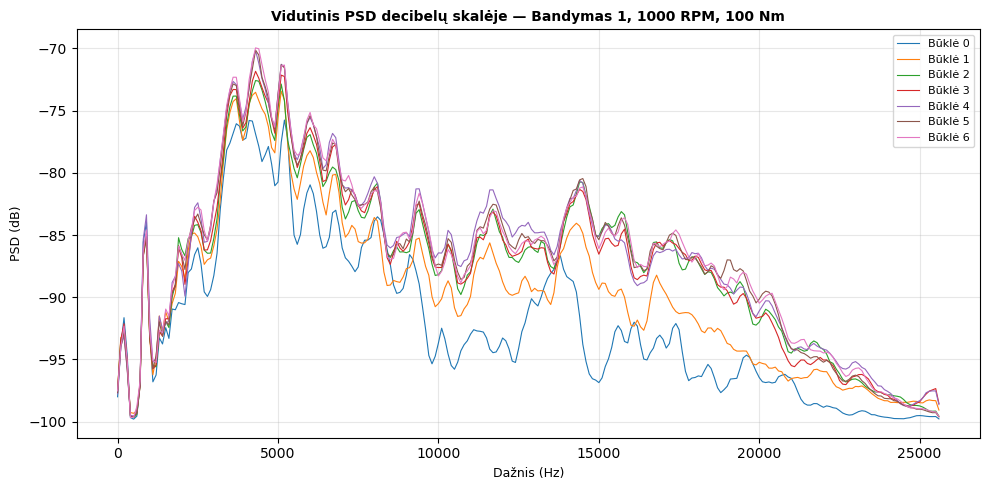

In [20]:
import matplotlib.mlab as mlab

TARGET_BATCH = 1
TARGET_RPM = 1000
TARGET_LOAD = 100
SHOW_LABELS = [0, 1, 2, 3, 4, 5, 6]

FS           = 51200
WINDOW_SIZE  = 16384
NPERSEG      = 512
NOVERLAP     = 256

psd_dummy, freqs = mlab.psd(
    np.zeros(WINDOW_SIZE), NFFT=NPERSEG, Fs=FS,
    noverlap=NOVERLAP, detrend=mlab.detrend_mean
)

fig, ax = plt.subplots(figsize=(10, 5))

for i, label in enumerate(SHOW_LABELS):
    mask = (
        (signal_groups['rpm'] == TARGET_RPM) &
        (signal_groups['load'] == TARGET_LOAD) &
        (signal_groups['label'] == label) &
        (signal_groups['batch'] == TARGET_BATCH)
    )
    sig = signal_groups[mask].iloc[0]['signal']

    n_segs = len(sig) // WINDOW_SIZE
    psds = []
    for s in range(n_segs):
        segment = sig[s * WINDOW_SIZE : (s + 1) * WINDOW_SIZE]
        psd, _ = mlab.psd(
            segment, NFFT=NPERSEG, Fs=FS,
            noverlap=NOVERLAP, detrend=mlab.detrend_mean
        )
        psds.append(10 * np.log10(psd + 1e-10))
    mean_psd = np.mean(psds, axis=0)

    ax.plot(freqs, mean_psd, linewidth=0.8, label=f'Būklė {label}')

ax.set_title(
    f'Vidutinis PSD decibelų skalėje — Bandymas {TARGET_BATCH}, '
    f'{TARGET_RPM} RPM, {TARGET_LOAD} Nm',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Dažnis (Hz)', fontsize=9)
ax.set_ylabel('PSD (dB)', fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('psd_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Signalų stacionarumo tikrinimas

In [10]:
from statsmodels.tsa.stattools import adfuller
import time

alpha = 0.05
max_lag = 50

results = []

for idx, row in signal_groups.iterrows():
    sig = row['signal']

    t0 = time.time()
    adf_stat, adf_p, *_ = adfuller(sig, maxlag=max_lag)
    elapsed = time.time() - t0

    results.append({
        'Gedimas': row['label'],
        'Bandymas': int(row['batch']),
        'RPM': row['rpm'],
        'Apkrova': row['load'],
        'ADF_stat': adf_stat,
        'ADF_p': adf_p,
        'Stacionarus': adf_p < alpha,
        'Laikas_s': elapsed
    })

    print(f'[{idx+1:3d}/349] Gedimas={row["label"]}, '
          f'B={int(row["batch"])}, {row["rpm"]}RPM, {row["load"]}Nm | '
          f'p={adf_p:.4f} | {elapsed:.2f}s')

res_df = pd.DataFrame(results)

n_total = len(res_df)
n_stac = res_df['Stacionarus'].sum()
avg_time = res_df['Laikas_s'].mean()

print(f'\n{"="*50}')
print(f'Signalų: {n_total}, ilgis: {len(signal_groups.iloc[0]["signal"]):,}')
print(f'maxlag: {max_lag}')
print(f'Vidutinis laikas per signalą: {avg_time:.2f}s')
print(f'Bendras laikas: {res_df["Laikas_s"].sum():.1f}s')
print(f'\nStacionarūs:    {n_stac}/{n_total} ({n_stac/n_total*100:.1f}%)')
print(f'Nestacionarūs:  {n_total - n_stac}/{n_total}')

non_stac = res_df[~res_df['Stacionarus']]
if len(non_stac) > 0:
    print(f'\nNestacionarūs signalai:')
    print(non_stac[['Gedimas', 'Bandymas', 'RPM', 'Apkrova',
                     'ADF_p', 'Laikas_s']].to_string(index=False))

[  1/349] Gedimas=0, B=1, 1000RPM, 25Nm | p=0.0000 | 19.68s
[  2/349] Gedimas=0, B=1, 2000RPM, 25Nm | p=0.0000 | 19.56s
[  3/349] Gedimas=0, B=1, 3000RPM, 25Nm | p=0.0000 | 19.69s
[  4/349] Gedimas=0, B=1, 4000RPM, 25Nm | p=0.0000 | 19.64s
[  5/349] Gedimas=0, B=1, 5000RPM, 25Nm | p=0.0000 | 19.63s
[  6/349] Gedimas=0, B=1, 1000RPM, 50Nm | p=0.0000 | 19.67s
[  7/349] Gedimas=0, B=1, 2000RPM, 50Nm | p=0.0000 | 19.69s
[  8/349] Gedimas=0, B=1, 3000RPM, 50Nm | p=0.0000 | 19.67s
[  9/349] Gedimas=0, B=1, 4000RPM, 50Nm | p=0.0000 | 19.67s
[ 10/349] Gedimas=0, B=1, 5000RPM, 50Nm | p=0.0000 | 19.61s
[ 11/349] Gedimas=0, B=1, 1000RPM, 75Nm | p=0.0000 | 20.22s
[ 12/349] Gedimas=0, B=1, 2000RPM, 75Nm | p=0.0000 | 20.29s
[ 13/349] Gedimas=0, B=1, 3000RPM, 75Nm | p=0.0000 | 20.16s
[ 14/349] Gedimas=0, B=1, 4000RPM, 75Nm | p=0.0000 | 20.18s
[ 15/349] Gedimas=0, B=1, 5000RPM, 75Nm | p=0.0000 | 20.33s
[ 16/349] Gedimas=0, B=1, 1000RPM, 100Nm | p=0.0000 | 20.07s
[ 17/349] Gedimas=0, B=1, 2000RPM, 100N